In [4]:
from typing import TypedDict

from dotenv import  load_dotenv
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph,START,END
from loguru import logger
load_dotenv(override=True)

model = ChatDeepSeek(
    model = "deepseek-v4-flash",
    extra_body={
        "thinking":{
            "type":"disabled"
        }
    }
)

#1. 声明状态
class OverAllState(TypedDict):
    topic:str
    poem:str
    joke:str
    final_output:str

#1.1 输入状态
class InputState(TypedDict):
    topic:str

#1.2 输出状态
class OutputState(TypedDict):
    final_output:str

#2. 声明节点
def node_poem(state:InputState) -> OverAllState:
    logger.info("node_poem正在执行")
    topic = state["topic"]
    poem = model.invoke([HumanMessage(f"写一首关于{topic}的七言绝句")]).content

    return {
        "poem":poem
    }

def node_joke(state:InputState) -> OverAllState:
    logger.info("node_joke正在执行")
    topic = state["topic"]
    joke = model.invoke([HumanMessage(f"写一首关于{topic}的笑话")]).content
    return {
        "joke":joke
    }

def node_output(state:OverAllState)->OutputState:
    logger.info("node_output正在执行")
    topic = state["topic"]
    poem = state["poem"]
    joke = state["joke"]
    final_output = f"关于{topic}主题的七言绝句:{poem},\n笑话:{joke}\n"
    return {
        "final_output":final_output
    }

#3. 构建图的结构
builder = StateGraph(state_schema=OverAllState,input_schema=InputState,output_schema=OutputState)
#3.1 添加节点
builder.add_node("node_poem",node_poem)
builder.add_node("node_joke",node_joke)
builder.add_node("node_output",node_output)
builder.add_edge(START,"node_poem")
builder.add_edge(START,"node_joke")
builder.add_edge("node_poem","node_output")
builder.add_edge("node_joke","node_output")
builder.add_edge("node_output",END)

#4. 添加检查点
checkpointer = InMemorySaver()
config = {
    "configurable":{
        "thread_id":"123"
    }
}

#5. 编译执行
graph = builder.compile(checkpointer=checkpointer)
res = graph.invoke({"topic":"莲花"},config=config)
print(res)


2026-07-07 14:26:26.395 | INFO     | __main__:node_poem:37 - node_poem正在执行
2026-07-07 14:26:26.397 | INFO     | __main__:node_joke:46 - node_joke正在执行
2026-07-07 14:26:29.255 | INFO     | __main__:node_output:54 - node_output正在执行


{'final_output': '关于莲花主题的七言绝句:《咏莲》\n一鉴方塘半亩风，翠云裁罢见瑶宫。\n凡花纵有十分色，怎比清涟浴骨红。\n\n注：我的创作思路是避开传统咏莲的直白描写，通过水塘、翠云等意象铺垫清绝之境。后两句采用对比手法，以凡花之艳反衬莲花出淤泥而不染的品格，“浴骨红”三字既暗合莲花色彩，又赋予其历经磨砺方显本真的深层意蕴，体现对高洁品格的礼赞。,\n笑话:莲花对荷叶说：“咱俩真奇怪，一个在泥里扎根，一个在水上漂。”  \n荷叶翻个白眼：“你懂什么？我这是‘出淤泥而不染’，你那是‘濯清涟而不妖’。”  \n莲花急了：“凭什么你天天被夸‘清净’，我就得‘妖娆’？”  \n荷叶淡定：“因为你是‘花’，而我是‘叶’——你们‘花’界，总是太浮夸。”  \n莲花气得红了脸：“好你个荷叶，我看你是‘叶公好龙’——表面清净，心里全是戏！”  \n荷叶大笑：“‘叶公好龙’？那你这朵‘莲花’是不是该叫‘莲中龙凤’？”\n'}


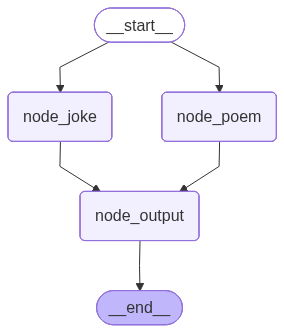

In [5]:
from IPython.display import  display
display(graph)

In [6]:
history_checkpoints = list(graph.get_state_history(config=config))
print(history_checkpoints)

[StateSnapshot(values={'topic': '莲花', 'poem': '《咏莲》\n一鉴方塘半亩风，翠云裁罢见瑶宫。\n凡花纵有十分色，怎比清涟浴骨红。\n\n注：我的创作思路是避开传统咏莲的直白描写，通过水塘、翠云等意象铺垫清绝之境。后两句采用对比手法，以凡花之艳反衬莲花出淤泥而不染的品格，“浴骨红”三字既暗合莲花色彩，又赋予其历经磨砺方显本真的深层意蕴，体现对高洁品格的礼赞。', 'joke': '莲花对荷叶说：“咱俩真奇怪，一个在泥里扎根，一个在水上漂。”  \n荷叶翻个白眼：“你懂什么？我这是‘出淤泥而不染’，你那是‘濯清涟而不妖’。”  \n莲花急了：“凭什么你天天被夸‘清净’，我就得‘妖娆’？”  \n荷叶淡定：“因为你是‘花’，而我是‘叶’——你们‘花’界，总是太浮夸。”  \n莲花气得红了脸：“好你个荷叶，我看你是‘叶公好龙’——表面清净，心里全是戏！”  \n荷叶大笑：“‘叶公好龙’？那你这朵‘莲花’是不是该叫‘莲中龙凤’？”', 'final_output': '关于莲花主题的七言绝句:《咏莲》\n一鉴方塘半亩风，翠云裁罢见瑶宫。\n凡花纵有十分色，怎比清涟浴骨红。\n\n注：我的创作思路是避开传统咏莲的直白描写，通过水塘、翠云等意象铺垫清绝之境。后两句采用对比手法，以凡花之艳反衬莲花出淤泥而不染的品格，“浴骨红”三字既暗合莲花色彩，又赋予其历经磨砺方显本真的深层意蕴，体现对高洁品格的礼赞。,\n笑话:莲花对荷叶说：“咱俩真奇怪，一个在泥里扎根，一个在水上漂。”  \n荷叶翻个白眼：“你懂什么？我这是‘出淤泥而不染’，你那是‘濯清涟而不妖’。”  \n莲花急了：“凭什么你天天被夸‘清净’，我就得‘妖娆’？”  \n荷叶淡定：“因为你是‘花’，而我是‘叶’——你们‘花’界，总是太浮夸。”  \n莲花气得红了脸：“好你个荷叶，我看你是‘叶公好龙’——表面清净，心里全是戏！”  \n荷叶大笑：“‘叶公好龙’？那你这朵‘莲花’是不是该叫‘莲中龙凤’？”\n'}, next=(), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f179ccc-9e2c-65ad-8002-cbe900473c83'}}, met

In [7]:
latest_history_checkpoint = graph.get_state(config=config)
print(latest_history_checkpoint)

StateSnapshot(values={'topic': '莲花', 'poem': '《咏莲》\n一鉴方塘半亩风，翠云裁罢见瑶宫。\n凡花纵有十分色，怎比清涟浴骨红。\n\n注：我的创作思路是避开传统咏莲的直白描写，通过水塘、翠云等意象铺垫清绝之境。后两句采用对比手法，以凡花之艳反衬莲花出淤泥而不染的品格，“浴骨红”三字既暗合莲花色彩，又赋予其历经磨砺方显本真的深层意蕴，体现对高洁品格的礼赞。', 'joke': '莲花对荷叶说：“咱俩真奇怪，一个在泥里扎根，一个在水上漂。”  \n荷叶翻个白眼：“你懂什么？我这是‘出淤泥而不染’，你那是‘濯清涟而不妖’。”  \n莲花急了：“凭什么你天天被夸‘清净’，我就得‘妖娆’？”  \n荷叶淡定：“因为你是‘花’，而我是‘叶’——你们‘花’界，总是太浮夸。”  \n莲花气得红了脸：“好你个荷叶，我看你是‘叶公好龙’——表面清净，心里全是戏！”  \n荷叶大笑：“‘叶公好龙’？那你这朵‘莲花’是不是该叫‘莲中龙凤’？”', 'final_output': '关于莲花主题的七言绝句:《咏莲》\n一鉴方塘半亩风，翠云裁罢见瑶宫。\n凡花纵有十分色，怎比清涟浴骨红。\n\n注：我的创作思路是避开传统咏莲的直白描写，通过水塘、翠云等意象铺垫清绝之境。后两句采用对比手法，以凡花之艳反衬莲花出淤泥而不染的品格，“浴骨红”三字既暗合莲花色彩，又赋予其历经磨砺方显本真的深层意蕴，体现对高洁品格的礼赞。,\n笑话:莲花对荷叶说：“咱俩真奇怪，一个在泥里扎根，一个在水上漂。”  \n荷叶翻个白眼：“你懂什么？我这是‘出淤泥而不染’，你那是‘濯清涟而不妖’。”  \n莲花急了：“凭什么你天天被夸‘清净’，我就得‘妖娆’？”  \n荷叶淡定：“因为你是‘花’，而我是‘叶’——你们‘花’界，总是太浮夸。”  \n莲花气得红了脸：“好你个荷叶，我看你是‘叶公好龙’——表面清净，心里全是戏！”  \n荷叶大笑：“‘叶公好龙’？那你这朵‘莲花’是不是该叫‘莲中龙凤’？”\n'}, next=(), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f179ccc-9e2c-65ad-8002-cbe900473c83'}}, meta

In [8]:
target_config = {
    "configurable": {
        "thread_id": "123",
        "checkpoint_id": "1f179ccc-82e1-65c1-8000-8d9b808356bc"
    }
}

snapshot = graph.get_state(config=target_config)
print(snapshot)

StateSnapshot(values={'topic': '莲花'}, next=('node_poem', 'node_joke'), config={'configurable': {'thread_id': '123', 'checkpoint_id': '1f179ccc-82e1-65c1-8000-8d9b808356bc'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-07T06:26:26.394861+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f179ccc-82de-62a6-bfff-29838637531e'}}, tasks=(PregelTask(id='60e681c2-9faa-ba0c-9d4b-df69fd802bda', name='node_poem', path=('__pregel_pull', 'node_poem'), error=None, interrupts=(), state=None, result={'poem': '《咏莲》\n一鉴方塘半亩风，翠云裁罢见瑶宫。\n凡花纵有十分色，怎比清涟浴骨红。\n\n注：我的创作思路是避开传统咏莲的直白描写，通过水塘、翠云等意象铺垫清绝之境。后两句采用对比手法，以凡花之艳反衬莲花出淤泥而不染的品格，“浴骨红”三字既暗合莲花色彩，又赋予其历经磨砺方显本真的深层意蕴，体现对高洁品格的礼赞。'}), PregelTask(id='9ae74118-d6bf-0099-1a69-151f3afb6040', name='node_joke', path=('__pregel_pull', 'node_joke'), error=None, interrupts=(), state=None, result={'joke': '莲花对荷叶说：“咱俩真奇怪，一个在泥里扎根，一个在水上漂。”  \n荷叶翻个白眼：“你懂什么？我这是‘出淤泥而不染’，你那是‘濯清涟而不妖’。”  \n莲花急了：“凭什么你天天被夸‘清净’

In [11]:
print('=' * 30, '-> 根据ID查看特定检查点 <-', '=' * 30)
checkpointe_id = history_checkpoints[-2].config["configurable"]["checkpoint_id"]
print(f"checkpointe_id: {checkpointe_id}")

target_config = {
    "configurable": {
        "thread_id": config["configurable"]["thread_id"],
        "checkpoint_id": checkpointe_id
    }
}

specific_history_checkpoint = graph.get_state(config=target_config)
print(specific_history_checkpoint)

============================== -> 根据ID查看特定检查点 <- ==============================
checkpointe_id: 1f179ccc-82e1-65c1-8000-8d9b808356bc
StateSnapshot(values={'topic': '莲花'}, next=('node_poem', 'node_joke'), config={'configurable': {'thread_id': '123', 'checkpoint_id': '1f179ccc-82e1-65c1-8000-8d9b808356bc'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-07T06:26:26.394861+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f179ccc-82de-62a6-bfff-29838637531e'}}, tasks=(PregelTask(id='60e681c2-9faa-ba0c-9d4b-df69fd802bda', name='node_poem', path=('__pregel_pull', 'node_poem'), error=None, interrupts=(), state=None, result={'poem': '《咏莲》\n一鉴方塘半亩风，翠云裁罢见瑶宫。\n凡花纵有十分色，怎比清涟浴骨红。\n\n注：我的创作思路是避开传统咏莲的直白描写，通过水塘、翠云等意象铺垫清绝之境。后两句采用对比手法，以凡花之艳反衬莲花出淤泥而不染的品格，“浴骨红”三字既暗合莲花色彩，又赋予其历经磨砺方显本真的深层意蕴，体现对高洁品格的礼赞。'}), PregelTask(id='9ae74118-d6bf-0099-1a69-151f3afb6040', name='node_joke', path=('__pregel_pull', 'node_joke'), error=None, inter